In [173]:
import pandas as pd
import os
import sys
sys.path.insert(0, "../")
from utils.ploting_figures import MakePlots

In [174]:
folder = "oneseed/"

In [175]:
dataframes = []

In [176]:
for archive in os.listdir(folder):
    if archive.endswith('.csv'):
        path = os.path.join(folder, archive)
        df = pd.read_csv(path)
        repr_name=os.path.splitext(archive)[0]
        if repr_name.startswith('metrics_one_hot'):
            df["encoder"]="one-hot"
        elif repr_name.startswith('metrics_frequency'):
            df["encoder"]="frequency"
        elif repr_name.startswith('metrics_pc'):
            end=repr_name.split('_')[-1]
            df["encoder"]=f"PC-{end}"
        elif repr_name.startswith('metrics_fft'):
            end=repr_name.split('_')[-1]
            df["encoder"]=f"FFT-{end}"
        else:
            df["encoder"]=repr_name
        dataframes.append(df)

dataframe = pd.concat(dataframes, ignore_index=True)

In [177]:
dataframe.drop(columns="iteration")
dataframe

,iteration,model,seed,sampling,Train_F1-score,Val_F1-score,Train_Recall,Val_Recall,Train_Precision,Val_Precision,Train_Accuracy,Val_Accuracy,encoder
0,0,AdaBoost,5,base,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,metrics_esm1b_t33_650M_UR50S
1,0,AdaBoost,5,undersampling,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,metrics_esm1b_t33_650M_UR50S
2,0,AdaBoost,5,oversampling,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,metrics_esm1b_t33_650M_UR50S
3,0,RandomForest,5,base,0.4920,0.5587,0.5105,0.5665,0.4882,0.5618,0.5105,0.5665,metrics_esm1b_t33_650M_UR50S
4,0,RandomForest,5,undersampling,0.5616,0.5505,0.5617,0.5470,0.5675,0.5584,0.5617,0.5470,metrics_esm1b_t33_650M_UR50S
...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,0,Lgbm,5,undersampling,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,metrics_ProstT5
596,0,Lgbm,5,oversampling,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,metrics_ProstT5
597,0,KNN,5,base,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,metrics_ProstT5
598,0,KNN,5,undersampling,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,metrics_ProstT5


In [178]:
dataframe.value_counts("seed").reset_index()
dataframe=dataframe[dataframe["seed"]==5]

In [179]:
dataframe

,iteration,model,seed,sampling,Train_F1-score,Val_F1-score,Train_Recall,Val_Recall,Train_Precision,Val_Precision,Train_Accuracy,Val_Accuracy,encoder
0,0,AdaBoost,5,base,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,metrics_esm1b_t33_650M_UR50S
1,0,AdaBoost,5,undersampling,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,metrics_esm1b_t33_650M_UR50S
2,0,AdaBoost,5,oversampling,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,metrics_esm1b_t33_650M_UR50S
3,0,RandomForest,5,base,0.4920,0.5587,0.5105,0.5665,0.4882,0.5618,0.5105,0.5665,metrics_esm1b_t33_650M_UR50S
4,0,RandomForest,5,undersampling,0.5616,0.5505,0.5617,0.5470,0.5675,0.5584,0.5617,0.5470,metrics_esm1b_t33_650M_UR50S
...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,0,Lgbm,5,undersampling,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,metrics_ProstT5
596,0,Lgbm,5,oversampling,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,metrics_ProstT5
597,0,KNN,5,base,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,metrics_ProstT5
598,0,KNN,5,undersampling,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,metrics_ProstT5


In [180]:
train=dataframe.filter(["model", "encoder", "sampling", "Train_F1-score", "Train_Recall", "Train_Precision", "Train_Accuracy"])
val=dataframe.filter(["model", "encoder", "sampling", "Val_F1-score", "Val_Recall", "Val_Precision", "Val_Accuracy"])

In [181]:
train.rename(columns={
    "Train_F1-score": "F1",
    "Train_Recall": "Recall",
    "Train_Precision": "Precision",
    "Train_Accuracy": "Accuracy"
}, inplace=True)
val.rename(columns={
    "Val_F1-score": "F1",
    "Val_Recall": "Recall",
    "Val_Precision": "Precision",
    "Val_Accuracy": "Accuracy"
}, inplace=True)
train["Stage"]="train"
val["Stage"]="val"
data=pd.concat([train, val], ignore_index=True)
data.rename(columns={
    "model": "Algorithm",
    "encoder": "Encoder",
    "sampling": "Sampling"
}, inplace=True)

In [182]:
data

,Algorithm,Encoder,Sampling,F1,Recall,Precision,Accuracy,Stage
0,AdaBoost,metrics_esm1b_t33_650M_UR50S,base,1.0000,1.0000,1.0000,1.0000,train
1,AdaBoost,metrics_esm1b_t33_650M_UR50S,undersampling,1.0000,1.0000,1.0000,1.0000,train
2,AdaBoost,metrics_esm1b_t33_650M_UR50S,oversampling,1.0000,1.0000,1.0000,1.0000,train
3,RandomForest,metrics_esm1b_t33_650M_UR50S,base,0.4920,0.5105,0.4882,0.5105,train
4,RandomForest,metrics_esm1b_t33_650M_UR50S,undersampling,0.5616,0.5617,0.5675,0.5617,train
...,...,...,...,...,...,...,...,...
1195,Lgbm,metrics_ProstT5,undersampling,1.0000,1.0000,1.0000,1.0000,val
1196,Lgbm,metrics_ProstT5,oversampling,1.0000,1.0000,1.0000,1.0000,val
1197,KNN,metrics_ProstT5,base,1.0000,1.0000,1.0000,1.0000,val
1198,KNN,metrics_ProstT5,undersampling,1.0000,1.0000,1.0000,1.0000,val


In [183]:
type_encoder = []
for index in data.index:
    name_encoder = data["Encoder"][index]

    if "FFT" in name_encoder:
        type_encoder.append("FFT-Based")
    elif "PC" in name_encoder:
        type_encoder.append("PHY-Based")
    elif "one-hot" in name_encoder:
        type_encoder.append("One-Hot-Based")
    elif "frequency" in name_encoder:
        type_encoder.append("Frequency-Based")
    else:
        type_encoder.append("Embedding-Based")
data["Type-Encoder"] = type_encoder

In [184]:
undersampling = data[data["Sampling"] == "undersampling"]
oversampling = data[data["Sampling"] == "oversampling"]
sampled = data[data["Sampling"] == "base"]

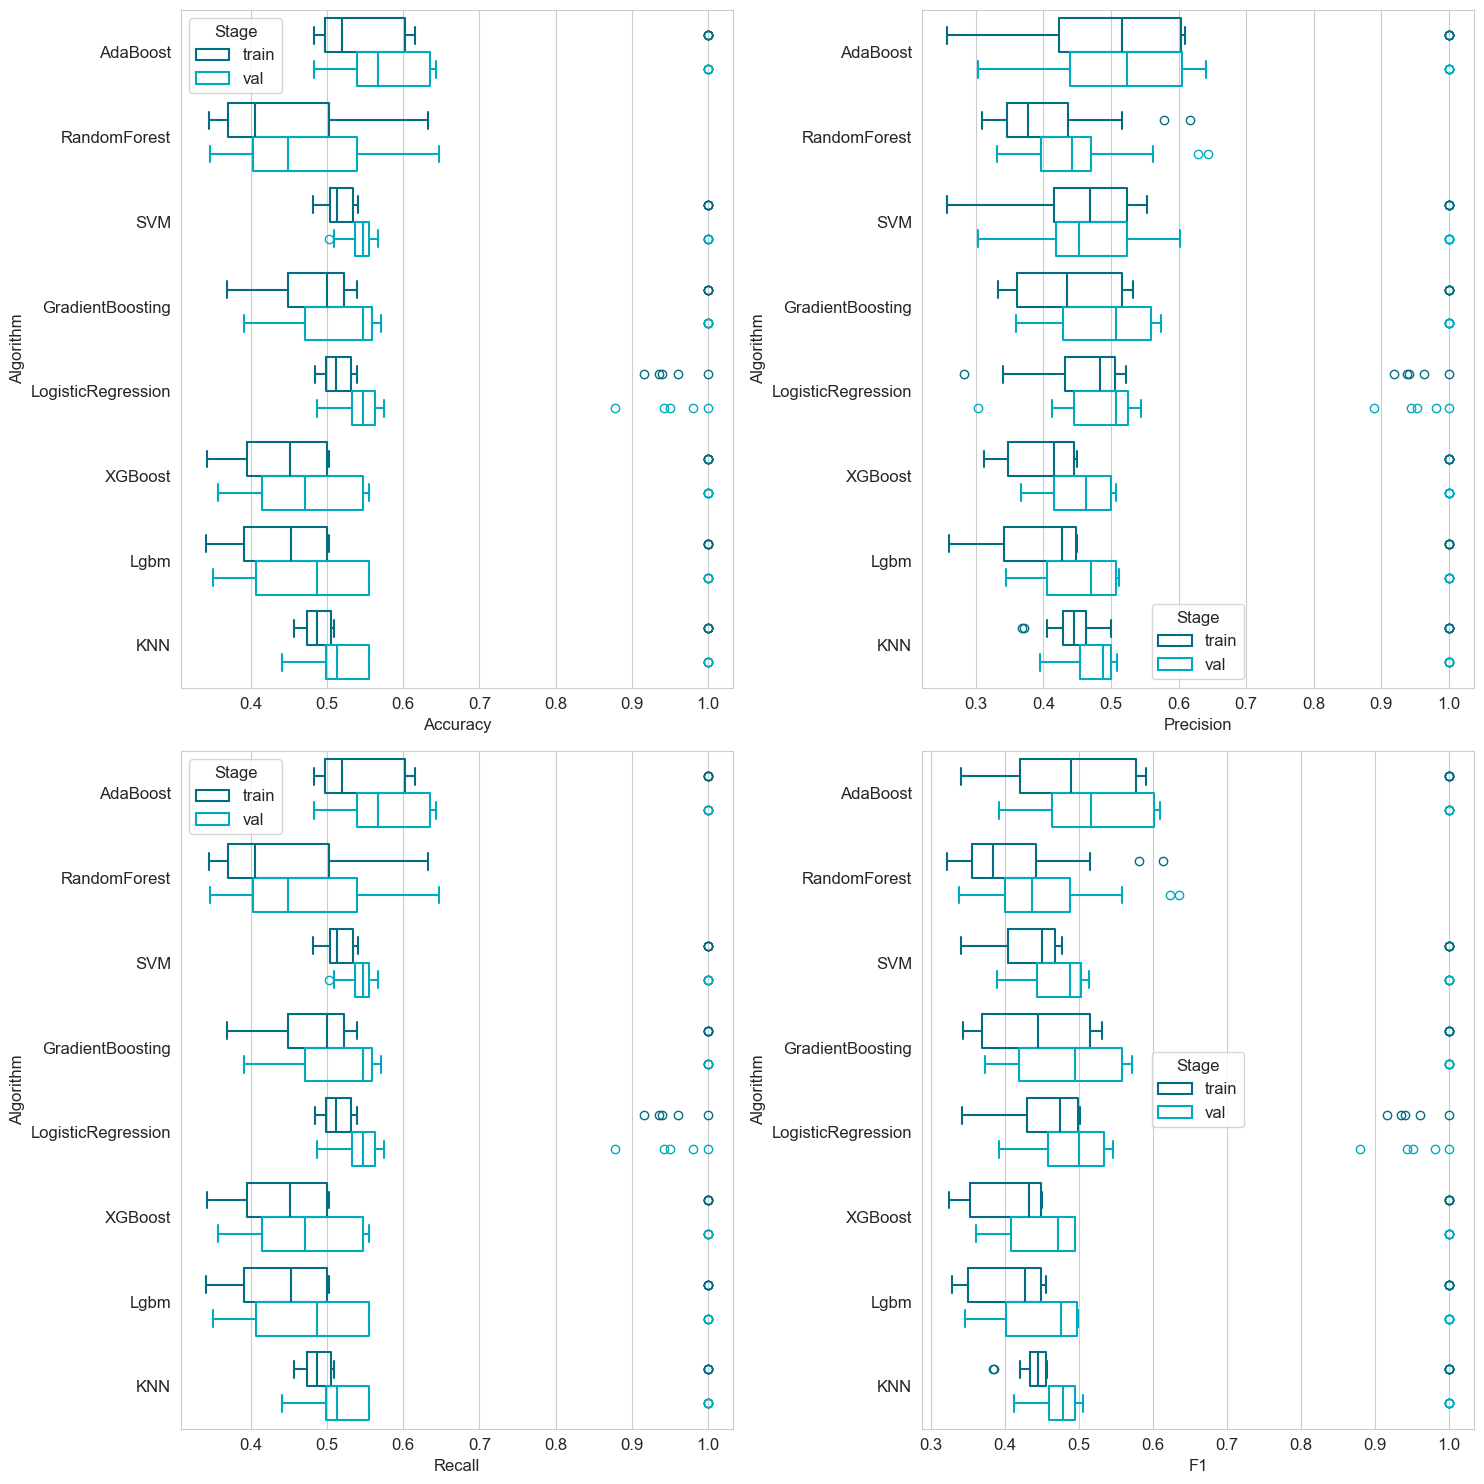

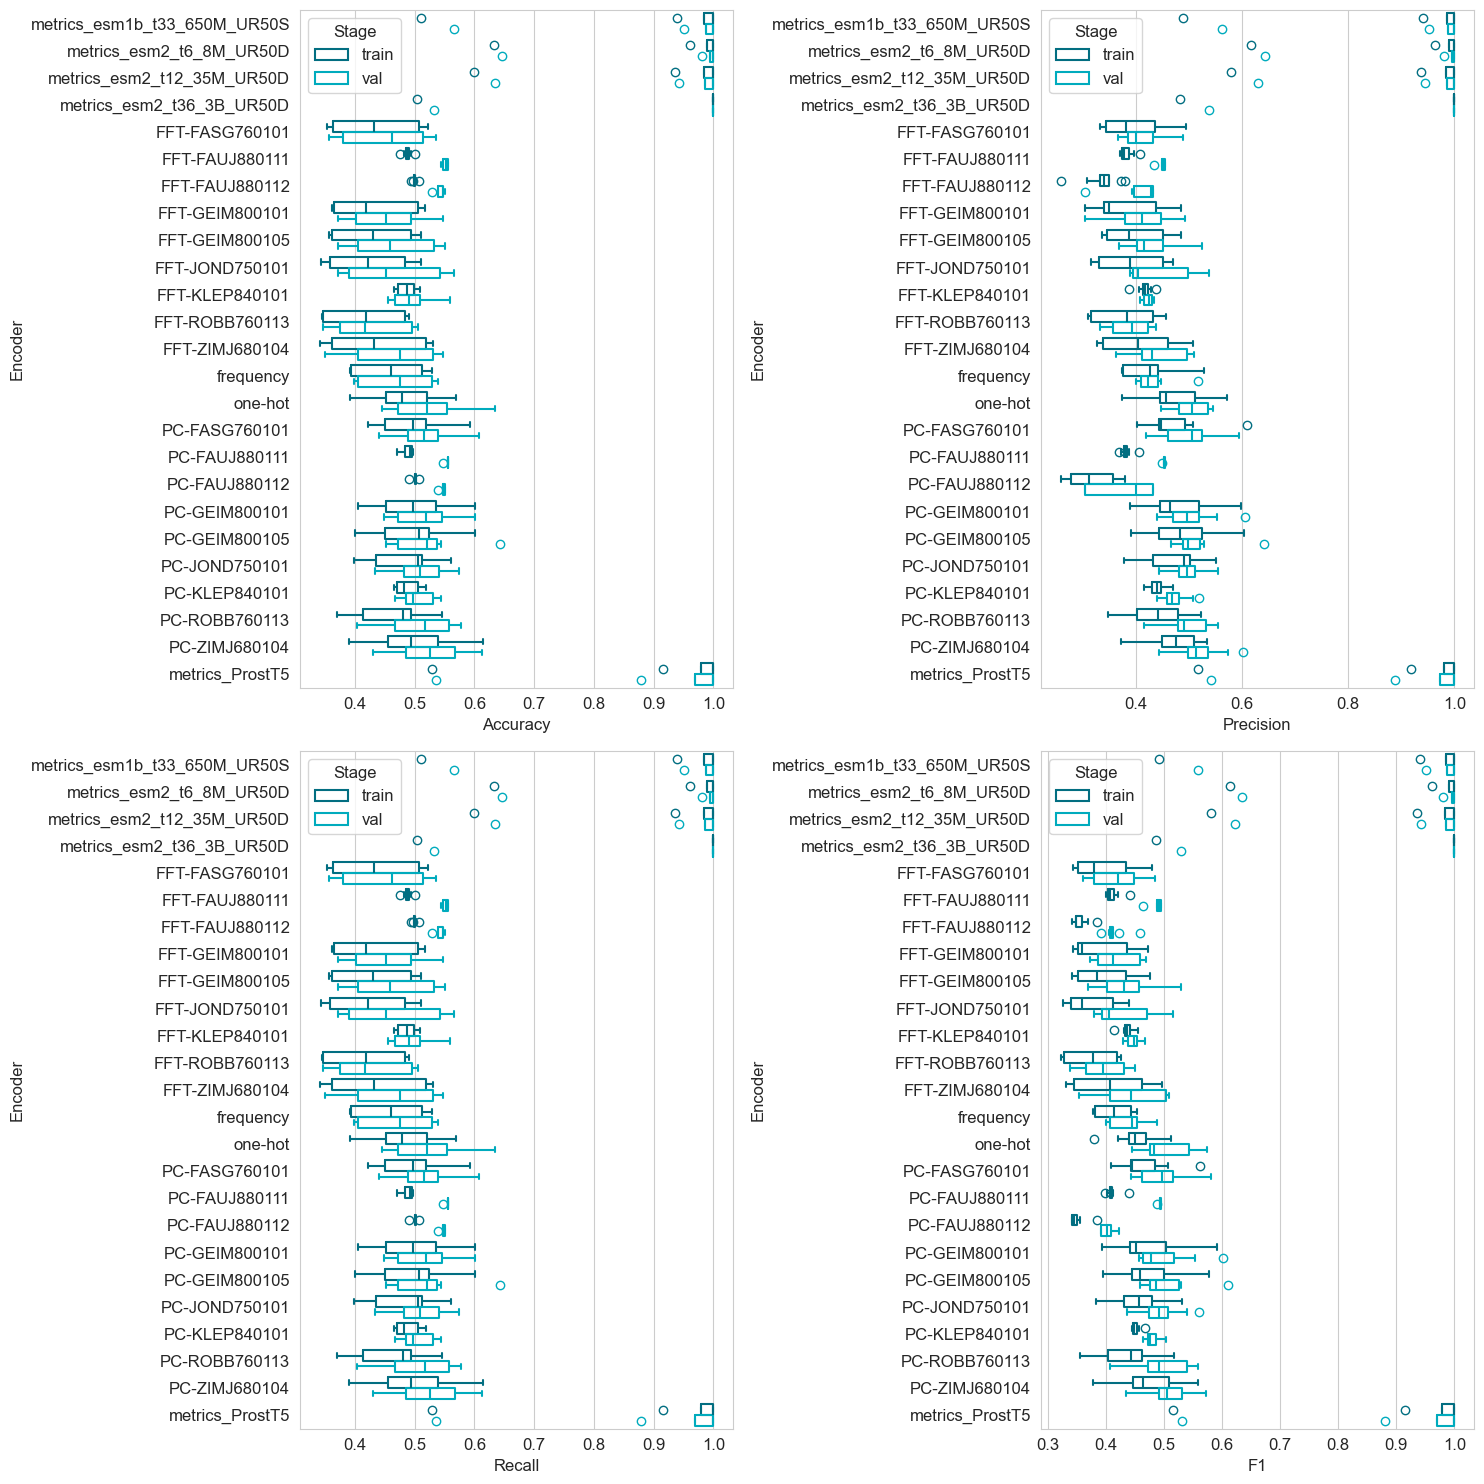

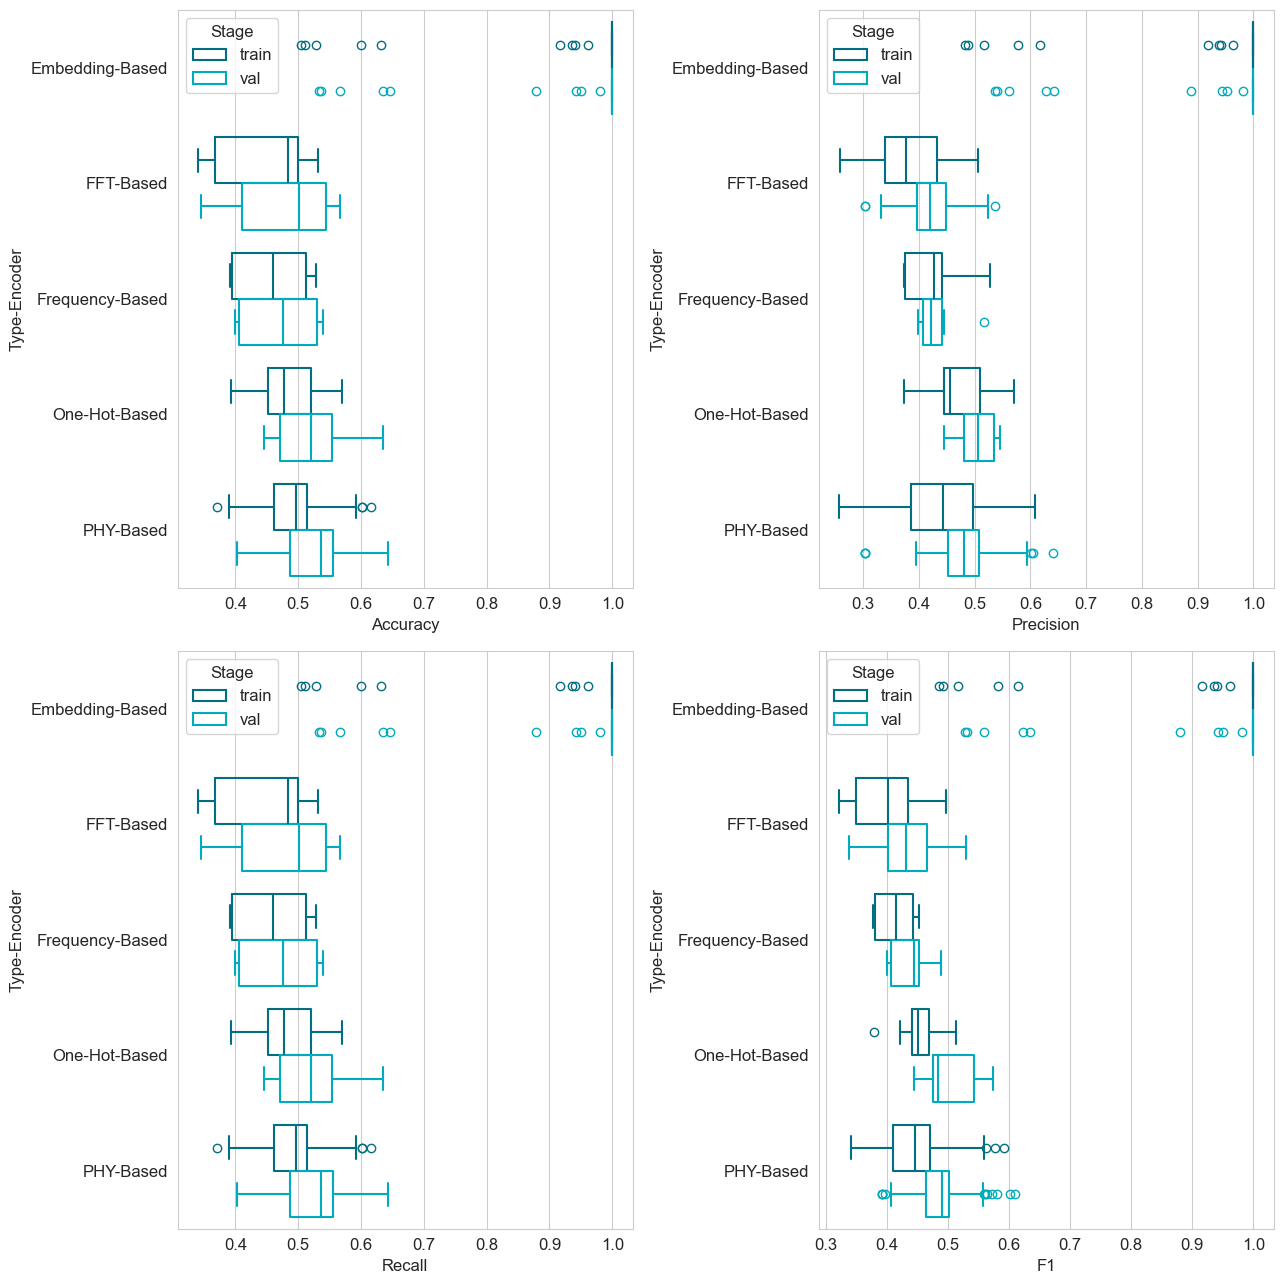

In [185]:
make_plots = MakePlots(dataset=sampled, path_export="../img/", hue="Stage", sample="Base")
make_plots.plot_by_algorithm()
make_plots.plot_by_encoder()
make_plots.plot_by_type_encoder()
#make_plots.plot_filter_by_nlp()